In [6]:
import pandas as pd

cleaned_df = pd.read_csv("cleaned_data.csv")
print(cleaned_df.head())
cleaned_df["Primary Type"]=cleaned_df["Primary Type"].astype("category")
cleaned_df["Domestic"]=cleaned_df["Domestic"].astype(int)
print(cleaned_df.head())

                 Primary Type                    Location Description  Arrest  \
0  OFFENSE INVOLVING CHILDREN                               residence       1   
1                   NARCOTICS                                sidewalk       1   
2             CRIMINAL DAMAGE  parking lot / garage (non residential)       0   
3                       THEFT  parking lot / garage (non residential)       0   
4                 SEX OFFENSE                               residence       0   

   Domestic  Year  
0     False  2022  
1     False  2023  
2     False  2023  
3     False  2023  
4     False  2021  
                 Primary Type                    Location Description  Arrest  \
0  OFFENSE INVOLVING CHILDREN                               residence       1   
1                   NARCOTICS                                sidewalk       1   
2             CRIMINAL DAMAGE  parking lot / garage (non residential)       0   
3                       THEFT  parking lot / garage (non residential)

In [7]:
print(cleaned_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90344 entries, 0 to 90343
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Primary Type          90344 non-null  category
 1   Location Description  90344 non-null  object  
 2   Arrest                90344 non-null  int64   
 3   Domestic              90344 non-null  int64   
 4   Year                  90344 non-null  int64   
dtypes: category(1), int64(3), object(1)
memory usage: 2.8+ MB
None


In [8]:
X=cleaned_df.drop(columns=["Arrest"])
y=cleaned_df["Arrest"]
print("X features:")
print(X)
print("y target:")
print(y)

X features:
                     Primary Type                    Location Description  \
0      OFFENSE INVOLVING CHILDREN                               residence   
1                       NARCOTICS                                sidewalk   
2                 CRIMINAL DAMAGE  parking lot / garage (non residential)   
3                           THEFT  parking lot / garage (non residential)   
4                     SEX OFFENSE                               residence   
...                           ...                                     ...   
90339  OFFENSE INVOLVING CHILDREN                               residence   
90340          DECEPTIVE PRACTICE                               apartment   
90341          DECEPTIVE PRACTICE                               residence   
90342                    HOMICIDE                                   porch   
90343                       THEFT                               residence   

       Domestic  Year  
0             0  2022  
1             0

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression

cleaned_df = cleaned_df.rename(columns={"Arrest": "y_reg"})

X = cleaned_df.drop("y_reg", axis=1)  
y = cleaned_df["y_reg"]  

print(X)
print(y)

                     Primary Type                    Location Description  \
0      OFFENSE INVOLVING CHILDREN                               residence   
1                       NARCOTICS                                sidewalk   
2                 CRIMINAL DAMAGE  parking lot / garage (non residential)   
3                           THEFT  parking lot / garage (non residential)   
4                     SEX OFFENSE                               residence   
...                           ...                                     ...   
90339  OFFENSE INVOLVING CHILDREN                               residence   
90340          DECEPTIVE PRACTICE                               apartment   
90341          DECEPTIVE PRACTICE                               residence   
90342                    HOMICIDE                                   porch   
90343                       THEFT                               residence   

       Domestic  Year  
0             0  2022  
1             0  2023  
2  

In [10]:
cleaned_df["y_clf"] = cleaned_df["Domestic"]
print(cleaned_df["y_clf"].value_counts())

y_clf
0    75477
1    14867
Name: count, dtype: int64


In [11]:
categorical_cols = ["Primary Type", "Location Description"]

cleaned_df_encoded = pd.get_dummies(cleaned_df, columns=categorical_cols, drop_first=True)
print(cleaned_df_encoded.head())

   y_reg  Domestic  Year  y_clf  Primary Type_ASSAULT  Primary Type_BATTERY  \
0      1         0  2022      0                 False                 False   
1      1         0  2023      0                 False                 False   
2      0         0  2023      0                 False                 False   
3      0         0  2023      0                 False                 False   
4      0         0  2021      0                 False                 False   

   Primary Type_BURGLARY  Primary Type_CONCEALED CARRY LICENSE VIOLATION  \
0                  False                                           False   
1                  False                                           False   
2                  False                                           False   
3                  False                                           False   
4                  False                                           False   

   Primary Type_CRIMINAL DAMAGE  Primary Type_CRIMINAL SEXUAL ASSAUL

In [12]:
X = cleaned_df_encoded.drop(["y_reg", "y_clf"], axis=1)
y_reg = cleaned_df_encoded["y_reg"]
y_clf = cleaned_df_encoded["y_clf"]

print(X)
print(y_reg)
print(y_clf)

       Domestic  Year  Primary Type_ASSAULT  Primary Type_BATTERY  \
0             0  2022                 False                 False   
1             0  2023                 False                 False   
2             0  2023                 False                 False   
3             0  2023                 False                 False   
4             0  2021                 False                 False   
...         ...   ...                   ...                   ...   
90339         1  2022                 False                 False   
90340         0  2025                 False                 False   
90341         0  2024                 False                 False   
90342         0  2025                 False                 False   
90343         0  2025                 False                 False   

       Primary Type_BURGLARY  Primary Type_CONCEALED CARRY LICENSE VIOLATION  \
0                      False                                           False   
1          

In [13]:

from sklearn.preprocessing import StandardScaler


X_reg_train,X_reg_test,y_reg_train,y_reg_test=train_test_split(X,y_reg,test_size=0.20,random_state=42)
X_clf_train,X_clf_test,y_clf_train,y_clf_test=train_test_split(X,y_clf,test_size=0.20,random_state=42)

scaler=StandardScaler()
X_reg_train_scaled=scaler.fit_transform(X_reg_train)
X_reg_test_scaled=scaler.transform(X_reg_test)

X_clf_train_scaled=scaler.fit_transform(X_clf_train)
X_clf_test_scaled=scaler.transform(X_clf_test)

Confusion Matrix:
 [[15099     0]
 [    0  2970]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     15099
           1       1.00      1.00      1.00      2970

    accuracy                           1.00     18069
   macro avg       1.00      1.00      1.00     18069
weighted avg       1.00      1.00      1.00     18069



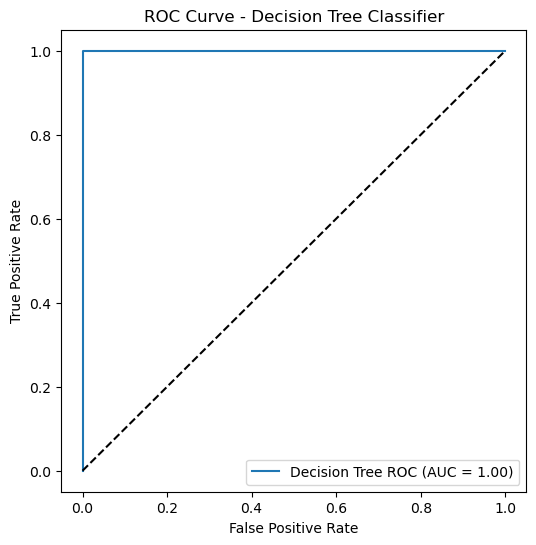

Decision Tree AUC: 1.0


In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_reg_train_scaled, y_clf_train)


y_dt_pred = dt_clf.predict(X_reg_test_scaled)
y_dt_proba = dt_clf.predict_proba(X_reg_test_scaled)[:,1]


print("Confusion Matrix:\n", confusion_matrix(y_clf_test, y_dt_pred))
print("Classification Report:\n", classification_report(y_clf_test, y_dt_pred))


fpr, tpr, thresholds = roc_curve(y_clf_test, y_dt_proba)
auc_dt = roc_auc_score(y_clf_test, y_dt_proba)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"Decision Tree ROC (AUC = {auc_dt:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree Classifier")
plt.legend(loc="lower right")
plt.show()

print("Decision Tree AUC:", auc_dt)

In [15]:
from sklearn.metrics import accuracy_score

train_acc = accuracy_score(y_clf_train, dt_clf.predict(X_reg_train_scaled))
test_acc = accuracy_score(y_clf_test, dt_clf.predict(X_reg_test_scaled))

print("Decision Tree Training Accuracy:", train_acc)
print("Decision Tree Test Accuracy:", test_acc)

Decision Tree Training Accuracy: 1.0
Decision Tree Test Accuracy: 1.0


In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_clf_tuned = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    random_state=42
)
dt_clf_tuned.fit(X_reg_train_scaled, y_clf_train)
train_acc_tuned = accuracy_score(y_clf_train, dt_clf_tuned.predict(X_reg_train_scaled))
test_acc_tuned = accuracy_score(y_clf_test, dt_clf_tuned.predict(X_reg_test_scaled))

print("Decision Tree (max_depth=5, min_samples_split=20)")
print("Training Accuracy:", train_acc_tuned)
print("Test Accuracy:", test_acc_tuned)

Decision Tree (max_depth=5, min_samples_split=20)
Training Accuracy: 1.0
Test Accuracy: 1.0


In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


dt_gini = DecisionTreeClassifier(max_depth=5, criterion='gini', random_state=42)
dt_gini.fit(X_reg_train_scaled, y_clf_train)
test_acc_gini = accuracy_score(y_clf_test, dt_gini.predict(X_reg_test_scaled))


dt_entropy = DecisionTreeClassifier(max_depth=5, criterion='entropy', random_state=42)
dt_entropy.fit(X_reg_train_scaled, y_clf_train)
test_acc_entropy = accuracy_score(y_clf_test, dt_entropy.predict(X_reg_test_scaled))

print("Decision Tree (criterion='gini') Test Accuracy:", test_acc_gini)
print("Decision Tree (criterion='entropy') Test Accuracy:", test_acc_entropy)

Decision Tree (criterion='gini') Test Accuracy: 1.0
Decision Tree (criterion='entropy') Test Accuracy: 1.0


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score


rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)
rf_clf.fit(X_reg_train_scaled, y_clf_train)


train_acc_rf = accuracy_score(y_clf_train, rf_clf.predict(X_reg_train_scaled))


test_acc_rf = accuracy_score(y_clf_test, rf_clf.predict(X_reg_test_scaled))


y_rf_proba = rf_clf.predict_proba(X_reg_test_scaled)[:,1]
auc_rf = roc_auc_score(y_clf_test, y_rf_proba)

print("Random Forest Training Accuracy:", train_acc_rf)
print("Random Forest Test Accuracy:", test_acc_rf)
print("Random Forest ROC-AUC:", auc_rf)




Random Forest Training Accuracy: 0.9999861639571083
Random Forest Test Accuracy: 1.0
Random Forest ROC-AUC: 1.0


In [19]:
import numpy as np


importances = rf_clf.feature_importances_
feature_names = X_reg_train.columns 

# Top 5 features
top_idx = importances.argsort()[::-1][:5]
for i in top_idx:
    print(f"{feature_names[i]}: {importances[i]:.4f}")

Domestic: 0.6554
Primary Type_BATTERY: 0.1054
Location Description_apartment: 0.0780
Location Description_residence: 0.0295
Primary Type_OFFENSE INVOLVING CHILDREN: 0.0238


In [20]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score


gb_clf = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb_clf.fit(X_reg_train_scaled, y_clf_train)

train_acc_gb = accuracy_score(y_clf_train, gb_clf.predict(X_reg_train_scaled))

test_acc_gb = accuracy_score(y_clf_test, gb_clf.predict(X_reg_test_scaled))

y_gb_proba = gb_clf.predict_proba(X_reg_test_scaled)[:,1]
auc_gb = roc_auc_score(y_clf_test, y_gb_proba)

print("Gradient Boosting Training Accuracy:", train_acc_gb)
print("Gradient Boosting Test Accuracy:", test_acc_gb)
print("Gradient Boosting ROC-AUC:", auc_gb)

Gradient Boosting Training Accuracy: 1.0
Gradient Boosting Test Accuracy: 1.0
Gradient Boosting ROC-AUC: 1.0


In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import numpy as np


rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)
rf_clf.fit(X_reg_train_scaled, y_clf_train)


y_rf_proba_full = rf_clf.predict_proba(X_reg_test_scaled)[:,1]
auc_full = roc_auc_score(y_clf_test, y_rf_proba_full)


importances = rf_clf.feature_importances_
feature_names = X_reg_train.columns
low_idx = importances.argsort()[:5]  # indices of 5 lowest importance
low_features = feature_names[low_idx]

print("Lowest-importance features:", list(low_features))
X_train_reduced = X_reg_train.drop(columns=low_features)
X_test_reduced = X_reg_test.drop(columns=low_features)


rf_clf_reduced = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)
rf_clf_reduced.fit(X_train_reduced, y_clf_train)


y_rf_proba_reduced = rf_clf_reduced.predict_proba(X_test_reduced)[:,1]
auc_reduced = roc_auc_score(y_clf_test, y_rf_proba_reduced)

print("Full model ROC-AUC:", auc_full)
print("Reduced model ROC-AUC:", auc_reduced)

Lowest-importance features: ['Location Description_airport transportation system (ats)', 'Location Description_coin operated machine', 'Location Description_club', 'Location Description_cha stairwell', 'Location Description_office']
Full model ROC-AUC: 1.0
Reduced model ROC-AUC: 1.0
